# If a patient could only try 5 treatments for brain fog, which should they be?

A conservative ranking of self-reported treatment outcomes in the same PatientPunk dataset used by `studies/psychedelics/psychedelics_analysis.ipynb`.

**Source:** `data/full_corpus_2026-07-31/records_covidlonghaulers_v2.json` — 69,161 patient records and 204,417 structured `treatment_outcome` entries from long-COVID / ME-CFS communities.

**Important:** This is hypothesis-generating observational evidence, not prescribing guidance. “Should try” means *the five treatments most strongly prioritized by this dataset for clinician discussion or further study*. It does not mean safe or appropriate for every patient.

## Methods

1. Parse the authoritative JSON into one row per `drug : outcome : symptom` entry.
2. Define the primary endpoint narrowly: the symptom slot explicitly contains **brain fog**, `brainfog`, or `brain-fog`. A broader cognitive endpoint is used only as a sensitivity analysis.
3. Canonicalize spelling, brand, and formulation variants for common treatments. Ordered, auditable regex rules are applied only to the treatment slot. Combination products remain separate unless the string names only one active treatment.
4. Collapse repeated entries to one result per patient and canonical treatment. The collapse is deliberately conservative: any `worsened` report dominates; conflicting positive and non-positive reports become `mixed`; only consistently helpful reports count as `helped`.
5. Rank treatments reported by at least **30 distinct patients** using a **Jeffreys-prior Bayesian posterior mean**, `(helped + 0.5) / (determinate + 1)`. Unlike ranking by the lower confidence bound, this gives smaller cohorts a fairer chance while applying mild shrinkage so a small perfect sample is not treated as literally 100% certain. Equal-tailed 95% beta-posterior credible intervals show uncertainty but do not determine rank. Psilocybin is explicitly included.

The five selected treatments are the top five by posterior mean. The 30-patient evidence floor is retained to prevent isolated anecdote clusters from dominating. No causal adjustment can remove Reddit self-selection, unverified exposure, treatment stacking, or the missing denominator of people who tried something and never posted about it.

In [1]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import beta


def find_repo_root(start=Path.cwd()):
    for directory in [start.resolve(), *start.resolve().parents]:
        candidate = directory / "data/full_corpus_2026-07-31/records_covidlonghaulers_v2.json"
        if candidate.is_file():
            return directory, candidate
    raise FileNotFoundError("Run from inside PatientPunk or place the dataset at its documented path")


REPO_ROOT, DATA_PATH = find_repo_root()
records = json.load(open(DATA_PATH))

OUTCOMES = {"helped", "worsened", "no_effect", "mixed", "unknown"}
rows = []
unparseable = []
for i, record in enumerate(records):
    fields = record.get("fields", {})
    values = (fields.get("treatment_outcome") or {}).get("values") or []
    values = [values] if isinstance(values, str) else values
    patient = record.get("record_meta", {}).get("author_hash") or f"missing_{i}"
    for raw in values:
        parts = [part.strip().lower() for part in raw.split(":")]
        if len(parts) < 2 or parts[1] not in OUTCOMES:
            unparseable.append(raw)
            continue
        rows.append({
            "patient": patient,
            "drug_string": parts[0],
            "outcome": parts[1],
            "symptom": parts[2] if len(parts) > 2 and parts[2] else None,
        })

assert not unparseable, f"Unexpected unparseable outcomes: {unparseable[:5]}"
outcomes = pd.DataFrame(rows)
print(f"Loaded {len(records):,} patients and parsed {len(outcomes):,} treatment outcomes.")

Loaded 69,161 patients and parsed 204,417 treatment outcomes.


In [2]:
PRIMARY_SYMPTOM_RE = re.compile(r"\bbrain\s*[- ]?\s*fog\b|\bbrainfog\b", re.I)
BROAD_COGNITIVE_RE = re.compile(
    r"brain\s*[- ]?\s*fog|brainfog|cognit|mental clarity|concentrat|"
    r"\bfocus\b|\bfocusing\b|\bmemory\b|memory loss|memory problems",
    re.I,
)

primary = outcomes[outcomes.symptom.fillna("").str.contains(PRIMARY_SYMPTOM_RE)].copy()
broad = outcomes[outcomes.symptom.fillna("").str.contains(BROAD_COGNITIVE_RE)].copy()

coverage = pd.DataFrame({
    "endpoint": ["explicit brain fog (primary)", "broader cognitive (sensitivity)"],
    "outcome_rows": [len(primary), len(broad)],
    "patients": [primary.patient.nunique(), broad.patient.nunique()],
    "raw_treatment_strings": [primary.drug_string.nunique(), broad.drug_string.nunique()],
})
display(coverage)
print("Most frequent primary symptom labels:")
display(primary.symptom.value_counts().head(12).rename("rows").to_frame())

,endpoint,outcome_rows,patients,raw_treatment_strings
0,explicit brain fog (primary),10259,6680,2243
1,broader cognitive (sensitivity),13203,7861,2643


Most frequent primary symptom labels:


,rows
symptom,
brain fog,10026
fatigue and brain fog,32
brainfog,25
energy and brain fog,12
brain fog and fatigue,8
dizziness and brain fog,4
"fatigue, brain fog",4
"brain fog, fatigue",4
brain fog and energy,4


In [3]:
# Ordered rules merge aliases, brands, spelling variants, and routes of the same treatment.
# Combination strings are caught first so they are not credited to either component alone.
CANONICAL_RULES = [
    ("Guanfacine + NAC", r"guanfacine\s*(?:\+|and)\s*(?:nac|n-acetyl)"),
    ("Psilocybin", r"psilocyb|psilocin|magic mushroom|\bshrooms?\b|psychedelic mushroom"),
    ("Low-dose naltrexone (LDN)", r"\bldn\b|low[- ]dose naltrexone"),
    ("Nicotine (patch/gum/unspecified)", r"\bnicotine\b|nicotine patches?|nicotine gum"),
    ("N-acetylcysteine (NAC)", r"^nac$|n-acetylcysteine|n acetyl cysteine"),
    ("Guanfacine", r"\bguanfacine\b"),
    ("Adderall", r"\badderall\b|mixed amphetamine salts"),
    ("Methylphenidate", r"\bmethylphenidate\b|\britalin\b|\bconcerta\b"),
    ("Lisdexamfetamine (Vyvanse)", r"\bvyvanse\b|lisdexamfetamine"),
    ("Modafinil", r"\bmodafinil\b|\bprovigil\b"),
    ("Bupropion (Wellbutrin)", r"\bwellbutrin\b|\bbupropion\b"),
    ("Fasting", r"\bintermittent fasting\b|^fasting$"),
    ("Creatine", r"\bcreatine\b"),
    ("Antihistamines (unspecified)", r"^antihistamines?$"),
    ("Nattokinase", r"\bnattokinase\b"),
    ("CoQ10/ubiquinol", r"\bcoq[- ]?10\b|\bubiquinol\b|coenzyme q10"),
    ("Niacin", r"^niacin$|nicotinic acid"),
    ("Lion's mane", r"lion'?s mane|lions mane"),
    ("Gabapentin", r"\bgabapentin\b"),
    ("Cannabis", r"^cannabis$|^marijuana$|^weed$|medical marijuana|\bthc\b"),
    ("Fluvoxamine", r"\bfluvoxamine\b"),
    ("Hyperbaric oxygen (HBOT)", r"\bhbot\b|hyperbaric oxygen"),
    ("Ketogenic diet", r"^keto(?: diet)?$|ketogenic diet"),
    ("Caffeine/coffee", r"^caffeine$|^coffee$"),
    ("Cetirizine (Zyrtec)", r"\bzyrtec\b|\bcetirizine\b"),
    ("Paxlovid", r"\bpaxlovid\b"),
    ("Aripiprazole (Abilify)", r"\babilify\b|\baripiprazole\b|^lda$|low dose abilify"),
    ("Famotidine (Pepcid)", r"\bfamotidine\b|\bpepcid\b"),
    ("Aspirin", r"^aspirin$|baby aspirin"),
    ("Vitamin B12", r"^b12$|vitamin b12|b12 injections?"),
    ("Methylene blue", r"methylene blue"),
    ("Vitamin D", r"^vitamin d3?$"),
    ("Low-histamine diet", r"low[- ]histamine diet"),
    ("Ketamine", r"\bketamine\b|\besketamine\b|\bspravato\b"),
]
COMPILED_RULES = [(name, re.compile(pattern, re.I)) for name, pattern in CANONICAL_RULES]


def canonicalize(drug_string):
    # Explicitly prevent functional mushrooms from entering the psilocybin arm.
    if re.search(r"lion'?s mane|lions mane|reishi|chaga|cordyceps|turkey tail|maitake|shiitake", drug_string, re.I):
        if re.search(r"lion'?s mane|lions mane", drug_string, re.I):
            return "Lion's mane"
        return drug_string.strip().title()
    for name, pattern in COMPILED_RULES:
        if pattern.search(drug_string):
            return name
    return drug_string.strip().title()

for frame in (primary, broad):
    frame["treatment"] = frame.drug_string.map(canonicalize)

assert canonicalize("magic mushrooms") == "Psilocybin"
assert canonicalize("lion's mane") == "Lion's mane"
assert canonicalize("guanfacine + nac") == "Guanfacine + NAC"
assert canonicalize("nicotinic acid") == "Niacin"
print(f"Canonicalization checks pass; {primary.treatment.nunique():,} primary treatment labels remain.")

Canonicalization checks pass; 2,116 primary treatment labels remain.


In [4]:
OUTCOME_ORDER = ["helped", "worsened", "no_effect", "mixed", "unknown"]


def collapse_patient_outcomes(values):
    observed = set(values) - {"unknown"}
    if "worsened" in observed:
        return "worsened"
    if observed == {"helped"}:
        return "helped"
    if "mixed" in observed or ("helped" in observed and len(observed) > 1):
        return "mixed"
    if "no_effect" in observed:
        return "no_effect"
    return "unknown"


def treatment_summary(frame, min_patients=30):
    patient_level = (
        frame.groupby(["patient", "treatment"], as_index=False)
             .agg(patient_outcome=("outcome", collapse_patient_outcomes),
                  raw_mentions=("outcome", "size"))
    )
    counts = (
        patient_level.groupby(["treatment", "patient_outcome"]).size()
        .unstack(fill_value=0)
        .reindex(columns=OUTCOME_ORDER, fill_value=0)
    )
    counts["patients"] = counts.sum(axis=1)
    counts["determinate"] = counts.patients - counts.unknown
    counts["helped_pct"] = 100 * counts.helped / counts.determinate
    counts["worsened_pct"] = 100 * counts.worsened / counts.determinate

    # Jeffreys prior Beta(0.5, 0.5): mild, symmetric shrinkage and finite estimates
    # even when every observed report is helpful or non-helpful.
    alpha_post = counts.helped + 0.5
    beta_post = counts.determinate - counts.helped + 0.5
    counts["posterior_mean"] = 100 * alpha_post / (alpha_post + beta_post)
    counts["credible_low"] = 100 * beta.ppf(0.025, alpha_post, beta_post)
    counts["credible_high"] = 100 * beta.ppf(0.975, alpha_post, beta_post)
    counts["eligible"] = counts.determinate >= min_patients
    counts["rank"] = np.nan
    eligible_order = counts[counts.eligible].sort_values(
        ["posterior_mean", "determinate"], ascending=False
    ).index
    counts.loc[eligible_order, "rank"] = np.arange(1, len(eligible_order) + 1)
    return patient_level, counts.sort_values(["eligible", "posterior_mean"], ascending=False)


patient_primary, summary_primary = treatment_summary(primary)
patient_broad, summary_broad = treatment_summary(broad)

columns = ["rank", "patients", "determinate", "helped", "worsened", "no_effect", "mixed",
           "helped_pct", "posterior_mean", "credible_low", "credible_high", "worsened_pct"]
leaders = summary_primary[summary_primary.eligible].head(20)[columns]
if "Psilocybin" not in leaders.index:
    leaders = pd.concat([leaders, summary_primary.loc[["Psilocybin"], columns]])

display(leaders.style.format({
    "rank": "{:.0f}", "helped_pct": "{:.1f}%", "posterior_mean": "{:.1f}%",
    "credible_low": "{:.1f}%", "credible_high": "{:.1f}%", "worsened_pct": "{:.1f}%",
}))

patient_outcome,rank,patients,determinate,helped,worsened,no_effect,mixed,helped_pct,posterior_mean,credible_low,credible_high,worsened_pct
treatment,,,,,,,,,,,,
Acupuncture,1,46,46,46,0,0,0,100.0%,98.9%,94.7%,100.0%,0.0%
Low-histamine diet,2,54,54,53,0,1,0,98.1%,97.3%,91.7%,99.8%,0.0%
Fish Oil,3,39,39,38,0,1,0,97.4%,96.2%,88.6%,99.7%,0.0%
Nicotine (patch/gum/unspecified),4,366,362,340,8,9,5,93.9%,93.8%,91.1%,96.0%,2.2%
Fasting,5,127,127,118,7,2,0,92.9%,92.6%,87.5%,96.4%,5.5%
Niacin,6,100,100,93,2,5,0,93.0%,92.6%,86.7%,96.8%,2.0%
Aspirin,7,60,59,55,3,1,0,93.2%,92.5%,84.7%,97.7%,5.1%
Tirzepatide,8,32,32,30,2,0,0,93.8%,92.4%,81.4%,98.7%,6.2%
Methylene blue,9,43,43,40,1,1,1,93.0%,92.0%,82.5%,98.0%,2.3%


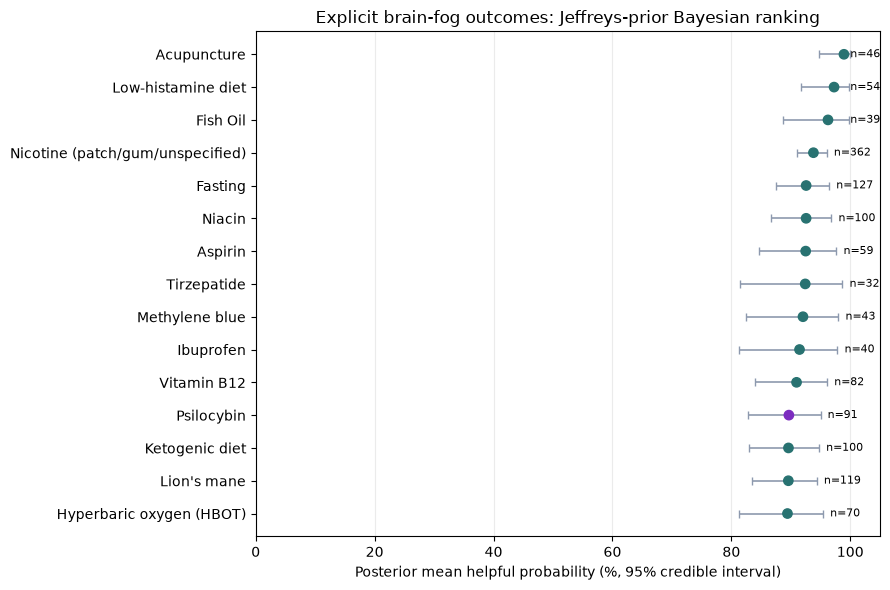

In [5]:
plot_data = summary_primary[summary_primary.eligible].head(15).sort_values("posterior_mean")
fig, ax = plt.subplots(figsize=(9, 6))
xerr = np.vstack([
    plot_data.posterior_mean - plot_data.credible_low,
    plot_data.credible_high - plot_data.posterior_mean,
])
colors = ["#7b2cbf" if name == "Psilocybin" else "#287271" for name in plot_data.index]
ax.errorbar(plot_data.posterior_mean, np.arange(len(plot_data)), xerr=xerr,
            fmt="none", ecolor="#8d99ae", capsize=3, linewidth=1.2)
ax.scatter(plot_data.posterior_mean, np.arange(len(plot_data)), c=colors, s=45, zorder=3)
ax.set_yticks(np.arange(len(plot_data)), plot_data.index)
ax.set_xlabel("Posterior mean helpful probability (%, 95% credible interval)")
ax.set_title("Explicit brain-fog outcomes: Jeffreys-prior Bayesian ranking")
ax.set_xlim(0, 105)
ax.grid(axis="x", alpha=.25)
ax.grid(axis="y", visible=False)
for y, (_, row) in enumerate(plot_data.iterrows()):
    ax.text(min(row.credible_high + 1.2, 100), y, f"n={int(row.determinate)}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
# Sensitivity: compare primary ranks with a broader cognitive endpoint.
comparison = (
    summary_primary[["rank", "determinate", "helped_pct", "posterior_mean"]]
    .rename(columns=lambda c: f"primary_{c}")
    .join(
        summary_broad[["rank", "determinate", "helped_pct", "posterior_mean"]]
        .rename(columns=lambda c: f"broad_{c}"),
        how="outer",
    )
)
comparison["rank_shift"] = comparison.broad_rank - comparison.primary_rank
focus_names = list(summary_primary[summary_primary.eligible].head(10).index)
if "Psilocybin" not in focus_names:
    focus_names.append("Psilocybin")
display(comparison.loc[focus_names].style.format({
    "primary_rank": "{:.0f}", "broad_rank": "{:.0f}", "rank_shift": "{:+.0f}",
    "primary_helped_pct": "{:.1f}%", "primary_posterior_mean": "{:.1f}%",
    "broad_helped_pct": "{:.1f}%", "broad_posterior_mean": "{:.1f}%",
}))

primary_top5 = list(summary_primary[summary_primary.eligible].head(5).index)
broad_top5 = list(summary_broad[summary_broad.eligible].head(5).index)
print("Primary top 5:", primary_top5)
print("Broad-endpoint top 5:", broad_top5)
print("Overlap:", sorted(set(primary_top5) & set(broad_top5)))

patient_outcome,primary_rank,primary_determinate,primary_helped_pct,primary_posterior_mean,broad_rank,broad_determinate,broad_helped_pct,broad_posterior_mean,rank_shift
treatment,,,,,,,,,
Acupuncture,1,46.000000,100.0%,98.9%,1,49,100.0%,99.0%,+0
Low-histamine diet,2,54.000000,98.1%,97.3%,4,61,95.1%,94.4%,+2
Fish Oil,3,39.000000,97.4%,96.2%,2,43,97.7%,96.6%,-1
Nicotine (patch/gum/unspecified),4,362.000000,93.9%,93.8%,5,463,94.2%,94.1%,+1
Fasting,5,127.000000,92.9%,92.6%,7,150,93.3%,93.0%,+2
Niacin,6,100.000000,93.0%,92.6%,8,105,93.3%,92.9%,+2
Aspirin,7,59.000000,93.2%,92.5%,10,66,92.4%,91.8%,+3
Tirzepatide,8,32.000000,93.8%,92.4%,22,37,89.2%,88.2%,+14
Methylene blue,9,43.000000,93.0%,92.0%,9,59,93.2%,92.5%,+0


Primary top 5: ['Acupuncture', 'Low-histamine diet', 'Fish Oil', 'Nicotine (patch/gum/unspecified)', 'Fasting']
Broad-endpoint top 5: ['Acupuncture', 'Fish Oil', 'Nadh', 'Low-histamine diet', 'Nicotine (patch/gum/unspecified)']
Overlap: ['Acupuncture', 'Fish Oil', 'Low-histamine diet', 'Nicotine (patch/gum/unspecified)']


In [7]:
recommendation = summary_primary[summary_primary.eligible].head(5).copy()
print("ANSWER — the five treatments prioritized by this dataset\n")
for position, (treatment, row) in enumerate(recommendation.iterrows(), 1):
    print(
        f"{position}. {treatment}: posterior mean {row.posterior_mean:.1f}% "
        f"({int(row.helped)}/{int(row.determinate)} consistently helpful reports; "
        f"95% credible interval {row.credible_low:.1f}–{row.credible_high:.1f}%; "
        f"{row.worsened_pct:.1f}% worsened)"
    )

psilo = summary_primary.loc["Psilocybin"]
print(
    f"\nPsilocybin ranks #{int(psilo['rank'])}: posterior mean {psilo.posterior_mean:.1f}% "
    f"({int(psilo.helped)}/{int(psilo.determinate)} consistently helpful; "
    f"95% credible interval {psilo.credible_low:.1f}–{psilo.credible_high:.1f}%)."
)

ANSWER — the five treatments prioritized by this dataset

1. Acupuncture: posterior mean 98.9% (46/46 consistently helpful reports; 95% credible interval 94.7–100.0%; 0.0% worsened)
2. Low-histamine diet: posterior mean 97.3% (53/54 consistently helpful reports; 95% credible interval 91.7–99.8%; 0.0% worsened)
3. Fish Oil: posterior mean 96.2% (38/39 consistently helpful reports; 95% credible interval 88.6–99.7%; 0.0% worsened)
4. Nicotine (patch/gum/unspecified): posterior mean 93.8% (340/362 consistently helpful reports; 95% credible interval 91.1–96.0%; 2.2% worsened)
5. Fasting: posterior mean 92.6% (118/127 consistently helpful reports; 95% credible interval 87.5–96.4%; 5.5% worsened)

Psilocybin ranks #12: posterior mean 89.7% (82/91 consistently helpful; 95% credible interval 82.7–95.0%).


## Interpretation and limitations

The answer above is a **prioritization**, not a treatment sequence. Ranking by posterior mean is intentionally more receptive to favorable smaller cohorts than ranking by a lower confidence bound. The Jeffreys prior adds only one pseudo-observation in total, so uncertainty remains visible in the credible intervals rather than dominating rank. Repeated mentions by one patient count once, and contradictory reports do not count as helpful.

Still, the ranking can be wrong clinically. The corpus is self-selected Reddit reporting, indications and disease severity differ across treatments, concurrent treatments are uncontrolled, exposures and diagnoses are unverified, and quiet nonresponse is underrepresented. The extraction model also over-calls positive outcomes. Patient records collapse years of posts, so timing, durability, and dose-response are unavailable. Some canonical groups—especially nicotine across patches, gum, and unspecified routes—remain heterogeneous.

These results support targeted clinical discussion and prospective comparison. Before any individual trial, a clinician should assess contraindications, interactions, dependence potential, psychiatric risk, cardiovascular/autonomic status, and whether the intervention is legal and medically supervised. That is especially important for prescription stimulants, nicotine, fasting, and psilocybin.

---
## Linear model: what predicts an intervention's reported response rate?

This section treats each eligible intervention as one observation and predicts its raw patient-level helpful percentage. It does **not** predict an individual patient's response and does not estimate causal efficacy.

Covariates are constructed without using the intervention's own target outcomes:

- number of patients reporting the intervention;
- reporters' helpful rate for their **other** treatments (the focal treatment is subtracted);
- reporters' overall treatment-reporting burden;
- reporter composition: age, female share, functional severity, improving/recovered share, and long-COVID duration;
- a coarse intervention class derived from the canonical treatment name.

A ridge linear model gives every intervention equal weight so large cohorts do not automatically dominate. Performance and feature utility use leave-one-intervention-out cross-validation. A covariate is useful predictively when removing it increases held-out RMSE; coefficients alone are not treated as evidence of utility.

In [8]:
def first_value(fields, name):
    value = (fields.get(name) or {}).get("values")
    if not value:
        return None
    return value[0] if isinstance(value, list) else value


def numeric_value(value, lower, upper):
    try:
        number = float(value)
        return number if lower <= number <= upper else np.nan
    except (TypeError, ValueError):
        return np.nan


metadata_rows = []
severity_map = {"mostly_functional": 0, "mild": 1, "moderate": 2,
                "housebound": 3, "severe": 4, "bedbound": 4}
for i, record in enumerate(records):
    fields = record.get("fields", {})
    patient = record.get("record_meta", {}).get("author_hash") or f"missing_{i}"
    sex = str(first_value(fields, "sex_gender") or "").lower()
    functional = str(first_value(fields, "functional_status_tier") or "").lower()
    trajectory = str(first_value(fields, "illness_trajectory") or "").lower()
    metadata_rows.append({
        "patient": patient,
        "age": numeric_value(first_value(fields, "age"), 5, 100),
        "female": 1.0 if re.search(r"female|woman|\bafab\b", sex) else
                  (0.0 if re.search(r"male|man|\bamab\b", sex) else np.nan),
        "severity": severity_map.get(functional, np.nan),
        "improving": 1.0 if trajectory in {"improving", "recovered"} else
                     (0.0 if trajectory in {"stable", "relapsing", "worsening"} else np.nan),
        "lc_duration_months": numeric_value(first_value(fields, "long_covid_duration_months"), 0, 240),
    })
patient_meta = pd.DataFrame(metadata_rows)

# Reporter positivity is calculated from all outcomes for OTHER treatments only.
all_for_baseline = outcomes.copy()
all_for_baseline["treatment"] = all_for_baseline.drug_string.map(canonicalize)
all_for_baseline["is_helped"] = (all_for_baseline.outcome == "helped").astype(int)
patient_totals = all_for_baseline.groupby("patient").agg(
    all_outcomes=("outcome", "size"), all_helped=("is_helped", "sum"),
    treatment_burden=("treatment", "nunique"),
)
patient_treatment_totals = all_for_baseline.groupby(["patient", "treatment"]).agg(
    focal_outcomes=("outcome", "size"), focal_helped=("is_helped", "sum"),
)

pairs = patient_primary[patient_primary.patient_outcome != "unknown"].copy()
pairs["helped_binary"] = (pairs.patient_outcome == "helped").astype(int)
pairs = pairs.join(patient_totals, on="patient").join(
    patient_treatment_totals, on=["patient", "treatment"]
).merge(patient_meta, on="patient", how="left")
pairs["other_outcomes"] = pairs.all_outcomes - pairs.focal_outcomes
pairs["other_help_rate"] = np.where(
    pairs.other_outcomes > 0,
    (pairs.all_helped - pairs.focal_helped) / pairs.other_outcomes,
    np.nan,
)

eligible_names = set(summary_primary[summary_primary.eligible].index)
pairs = pairs[pairs.treatment.isin(eligible_names)]
interventions = pairs.groupby("treatment").agg(
    response_rate=("helped_binary", "mean"),
    patients=("patient", "nunique"),
    other_help_rate=("other_help_rate", "mean"),
    treatment_burden=("treatment_burden", "mean"),
    functional_severity=("severity", "mean"),
    improving_share=("improving", "mean"),
    female_share=("female", "mean"),
    mean_age=("age", "mean"),
    mean_duration=("lc_duration_months", "mean"),
).reset_index()
interventions["response_rate"] *= 100
interventions["log_patients"] = np.log1p(interventions.patients)


def intervention_class(name):
    s = name.lower()
    if re.search(r"diet|fasting|carnivore|exercise|meditation|pacing", s):
        return "diet_lifestyle"
    if re.search(r"acupuncture|hyperbaric|hbot|cpap|block|tms|therapy|sauna", s):
        return "procedure_device"
    if re.search(r"psilocybin|ketamine|nicotine|cannabis|caffeine|coffee", s):
        return "psychoactive"
    if re.search(r"vitamin|fish oil|niacin|creatine|n-acetyl|coq|ubiquinol|lion|"
                 r"magnesium|nadh|omega|quercetin|thiamine|ginkgo|electrolyte|"
                 r"lactoferrin|b12|turmeric|supplement", s):
        return "supplement"
    return "medication_other"

interventions["intervention_class"] = interventions.treatment.map(intervention_class)
print(f"Modeling {len(interventions)} interventions with at least 30 determinate patient reports.")
display(interventions.head())

Modeling 54 interventions with at least 30 determinate patient reports.


,treatment,response_rate,patients,other_help_rate,treatment_burden,functional_severity,improving_share,female_share,mean_age,mean_duration,log_patients,intervention_class
0,Acupuncture,100.000000,46,0.764763,7.173913,2.225000,0.500000,0.739130,41.055556,29.043478,3.850148,procedure_device
1,Adderall,84.000000,175,0.675599,8.405714,2.403846,0.368056,0.625000,35.604396,34.225806,5.170484,medication_other
2,Allegra,90.000000,30,0.745610,12.033333,1.760000,0.640000,0.473684,34.230769,23.052632,3.433987,medication_other
3,Antihistamines (unspecified),76.785714,112,0.707569,9.500000,2.081633,0.639175,0.608696,33.882353,23.787879,4.727388,medication_other
4,Aripiprazole (Abilify),86.315789,95,0.640452,10.810526,2.500000,0.452381,0.622642,32.311111,30.280000,4.564348,medication_other


In [9]:
continuous_features = [
    "log_patients", "other_help_rate", "treatment_burden", "functional_severity",
    "improving_share", "female_share", "mean_age", "mean_duration",
]
class_dummies = pd.get_dummies(
    interventions.intervention_class, prefix="class", drop_first=True, dtype=float
)
X_full = pd.concat([interventions[continuous_features], class_dummies], axis=1)
y = interventions.response_rate.to_numpy(float)
ALPHAS = np.array([0.01, 0.1, 1.0, 10.0, 100.0])


def ridge_fit_predict(X_train, y_train, X_test, alpha):
    X_train = np.asarray(X_train, float).copy()
    X_test = np.asarray(X_test, float).copy()
    medians = np.nanmedian(X_train, axis=0)
    X_train = np.where(np.isnan(X_train), medians, X_train)
    X_test = np.where(np.isnan(X_test), medians, X_test)
    means = X_train.mean(axis=0)
    scales = X_train.std(axis=0)
    scales[scales < 1e-12] = 1.0
    X_train = (X_train - means) / scales
    X_test = (X_test - means) / scales
    design = np.column_stack([np.ones(len(X_train)), X_train])
    penalty = np.diag([0.0] + [alpha] * X_train.shape[1])
    coef = np.linalg.solve(design.T @ design + penalty, design.T @ y_train)
    return np.column_stack([np.ones(len(X_test)), X_test]) @ coef


def loo_predictions(X, target, alpha):
    X = np.asarray(X, float)
    predictions = np.empty(len(target))
    for test_idx in range(len(target)):
        train = np.arange(len(target)) != test_idx
        predictions[test_idx] = ridge_fit_predict(
            X[train], target[train], X[[test_idx]], alpha
        )[0]
    return predictions


def nested_loo_predictions(X, target):
    X = np.asarray(X, float)
    predictions = np.empty(len(target))
    selected_alphas = []
    for test_idx in range(len(target)):
        train = np.arange(len(target)) != test_idx
        X_train, y_train = X[train], target[train]
        inner_rmse = [
            np.sqrt(np.mean((loo_predictions(X_train, y_train, alpha) - y_train) ** 2))
            for alpha in ALPHAS
        ]
        alpha = ALPHAS[int(np.argmin(inner_rmse))]
        selected_alphas.append(alpha)
        predictions[test_idx] = ridge_fit_predict(
            X_train, y_train, X[[test_idx]], alpha
        )[0]
    return predictions, np.array(selected_alphas)


predictions, selected_alphas = nested_loo_predictions(X_full, y)
baseline_predictions = np.array([(y.sum() - y[i]) / (len(y) - 1) for i in range(len(y))])
rmse = np.sqrt(np.mean((predictions - y) ** 2))
baseline_rmse = np.sqrt(np.mean((baseline_predictions - y) ** 2))
r2_cv = 1 - np.sum((predictions - y) ** 2) / np.sum((y - y.mean()) ** 2)

print(f"Nested leave-one-intervention-out RMSE: {rmse:.2f} percentage points")
print(f"Mean-only baseline RMSE:               {baseline_rmse:.2f} percentage points")
print(f"Cross-validated R²:                    {r2_cv:.3f}")
print("Selected ridge alpha counts:", pd.Series(selected_alphas).value_counts().sort_index().to_dict())

predicted_table = interventions[["treatment", "response_rate", "patients"]].copy()
predicted_table["predicted_rate"] = predictions
predicted_table["residual"] = predicted_table.response_rate - predicted_table.predicted_rate
display(predicted_table.sort_values("predicted_rate", ascending=False).head(15).style.format({
    "response_rate": "{:.1f}%", "predicted_rate": "{:.1f}%", "residual": "{:+.1f} pp",
}))

Nested leave-one-intervention-out RMSE: 13.37 percentage points
Mean-only baseline RMSE:               14.64 percentage points
Cross-validated R²:                    0.134
Selected ridge alpha counts: {100.0: 54}


,treatment,response_rate,patients,predicted_rate,residual
23,Hyperbaric oxygen (HBOT),90.0%,70,90.3%,-0.3 pp
32,Low-histamine diet,98.1%,54,89.1%,+9.0 pp
15,Creatine,87.0%,77,88.4%,-1.4 pp
40,N-acetylcysteine (NAC),85.3%,217,88.4%,-3.2 pp
19,Fish Oil,97.4%,39,87.9%,+9.5 pp
29,Lion's mane,89.9%,119,87.1%,+2.8 pp
18,Fasting,92.9%,127,86.8%,+6.2 pp
52,Vitamin B12,91.5%,82,85.6%,+5.9 pp
10,Carnivore Diet,90.0%,30,85.4%,+4.6 pp
51,Tirzepatide,93.8%,32,84.9%,+8.8 pp


In [10]:
feature_groups = {
    "sample size (log patients)": ["log_patients"],
    "reporters' other-treatment helpful rate": ["other_help_rate"],
    "reporters' treatment burden": ["treatment_burden"],
    "functional severity": ["functional_severity"],
    "improving/recovered share": ["improving_share"],
    "female share": ["female_share"],
    "mean age": ["mean_age"],
    "mean Long-COVID duration": ["mean_duration"],
    "intervention class": list(class_dummies.columns),
}

utility_rows = []
for label, columns_to_drop in feature_groups.items():
    reduced = X_full.drop(columns=columns_to_drop)
    reduced_predictions, _ = nested_loo_predictions(reduced, y)
    reduced_rmse = np.sqrt(np.mean((reduced_predictions - y) ** 2))
    utility_rows.append({
        "covariate": label,
        "RMSE_without": reduced_rmse,
        "delta_RMSE": reduced_rmse - rmse,
        "predictively_useful": reduced_rmse > rmse,
    })
utility = pd.DataFrame(utility_rows).sort_values("delta_RMSE", ascending=False)
display(utility.style.format({"RMSE_without": "{:.2f} pp", "delta_RMSE": "{:+.2f} pp"}))

# Standardized full-data coefficients describe direction; utility is determined above by CV.
global_cv = {
    alpha: np.sqrt(np.mean((loo_predictions(X_full, y, alpha) - y) ** 2))
    for alpha in ALPHAS
}
best_alpha = min(global_cv, key=global_cv.get)
X_array = X_full.to_numpy(float)
medians = np.nanmedian(X_array, axis=0)
X_imputed = np.where(np.isnan(X_array), medians, X_array)
means, scales = X_imputed.mean(axis=0), X_imputed.std(axis=0)
scales[scales < 1e-12] = 1.0
X_scaled = (X_imputed - means) / scales
design = np.column_stack([np.ones(len(y)), X_scaled])
penalty = np.diag([0.0] + [best_alpha] * X_scaled.shape[1])
coef = np.linalg.solve(design.T @ design + penalty, design.T @ y)
coefficient_table = pd.DataFrame({
    "covariate": X_full.columns,
    "standardized_coefficient_pp": coef[1:],
}).sort_values("standardized_coefficient_pp", key=abs, ascending=False)
print(f"Full-data descriptive coefficient fit uses alpha={best_alpha:g}.")
display(coefficient_table.style.format({"standardized_coefficient_pp": "{:+.2f} pp"}))

,covariate,RMSE_without,delta_RMSE,predictively_useful
1,reporters' other-treatment helpful rate,13.80 pp,+0.43 pp,True
4,improving/recovered share,13.75 pp,+0.38 pp,True
8,intervention class,13.63 pp,+0.26 pp,True
0,sample size (log patients),13.47 pp,+0.11 pp,True
6,mean age,13.43 pp,+0.07 pp,True
3,functional severity,13.41 pp,+0.05 pp,True
7,mean Long-COVID duration,13.39 pp,+0.02 pp,True
2,reporters' treatment burden,13.28 pp,-0.09 pp,False
5,female share,13.27 pp,-0.10 pp,False


Full-data descriptive coefficient fit uses alpha=100.


,covariate,standardized_coefficient_pp
4,improving_share,+1.83 pp
1,other_help_rate,+1.26 pp
3,functional_severity,-1.14 pp
8,class_medication_other,-1.08 pp
0,log_patients,+0.89 pp
9,class_procedure_device,+0.80 pp
6,mean_age,+0.80 pp
11,class_supplement,+0.75 pp
7,mean_duration,+0.45 pp
2,treatment_burden,+0.32 pp


### Model conclusion

The model has **modest predictive value**, not enough for individualized or causal claims: nested leave-one-intervention-out RMSE is 13.37 percentage points versus 14.64 for a mean-only baseline (cross-validated R² = 0.134).

The clearest useful predictors are:

1. **Reporters' response to their other treatments** (removal worsens CV RMSE by 0.43 pp; positive coefficient). This is a reporting/patient-selection effect: interventions used by generally positive reporters also receive higher brain-fog ratings.
2. **Share already improving or recovered** (+0.38 pp; positive). This is likely prognosis/confounding by trajectory, not a treatment property.
3. **Intervention class** (+0.26 pp). Procedure/device and supplement indicators are positive descriptively, while the broad medication/other class is negative relative to diet/lifestyle; these classes are coarse and should not be read causally.

Sample size adds little (+0.11 pp). Mean age (+0.07), functional severity (+0.05), and duration (+0.02) add negligible held-out information. Treatment burden (−0.09) and female share (−0.10) make prediction slightly worse and are not useful here.

The dominant lesson is that **who reports the intervention predicts observed response more clearly than most clinical covariates**. Because the full model explains only 13.4% of held-out between-intervention variation, predicted rates should not replace each intervention's observed estimate.

### Continuation: residual ranking and a reduced model

The full model is dominated by who reports each treatment, not by clinical phenotype. Two follow-ups make that usable:

1. **Leave-one-out residuals** (`observed − predicted`) flag interventions that still look unusually good or bad *after* adjusting for reporter mix, trajectory share, class, and sample size. Positive residual ≠ proven efficacy, but it is a cleaner prioritization signal than the raw rate alone.
2. A **reduced ridge model** keeps only the four covariates with meaningful CV utility (`other_help_rate`, `improving_share`, intervention class, `log_patients`) and drops the near-noise clinical averages.

In [11]:
useful_columns = (
    ["other_help_rate", "improving_share", "log_patients"] + list(class_dummies.columns)
)
X_reduced = X_full[useful_columns]
reduced_predictions, reduced_alphas = nested_loo_predictions(X_reduced, y)
reduced_rmse = np.sqrt(np.mean((reduced_predictions - y) ** 2))
reduced_r2 = 1 - np.sum((reduced_predictions - y) ** 2) / np.sum((y - y.mean()) ** 2)

print("Model comparison (nested leave-one-intervention-out)")
print(f"  Mean-only baseline RMSE: {baseline_rmse:.2f} pp")
print(f"  Full model RMSE / R²:    {rmse:.2f} pp / {r2_cv:.3f}")
print(f"  Reduced model RMSE / R²: {reduced_rmse:.2f} pp / {reduced_r2:.3f}")
print("  Reduced alpha counts:", pd.Series(reduced_alphas).value_counts().sort_index().to_dict())

# Prefer reduced-model LOO residuals when the reduced fit is not worse.
use_reduced = reduced_rmse <= rmse + 1e-9
active_predictions = reduced_predictions if use_reduced else predictions
active_label = "reduced" if use_reduced else "full"
print(f"\nResidual ranking uses the {active_label} leave-one-out predictions.")

residual_table = interventions[["treatment", "response_rate", "patients", "intervention_class"]].copy()
residual_table["predicted_rate"] = active_predictions
residual_table["residual_pp"] = residual_table.response_rate - residual_table.predicted_rate
residual_table["abs_residual"] = residual_table.residual_pp.abs()
residual_table = residual_table.sort_values("residual_pp", ascending=False).reset_index(drop=True)
residual_table["residual_rank"] = residual_table.index + 1

print("\nTop 10 interventions beating reporter-mix expectation (positive residual):")
display(residual_table.head(10)[[
    "residual_rank", "treatment", "patients", "response_rate", "predicted_rate", "residual_pp", "intervention_class"
]].style.format({
    "response_rate": "{:.1f}%", "predicted_rate": "{:.1f}%", "residual_pp": "{:+.1f} pp",
}))

print("\nBottom 10 interventions lagging reporter-mix expectation (negative residual):")
display(residual_table.tail(10).sort_values("residual_pp")[[
    "residual_rank", "treatment", "patients", "response_rate", "predicted_rate", "residual_pp", "intervention_class"
]].style.format({
    "response_rate": "{:.1f}%", "predicted_rate": "{:.1f}%", "residual_pp": "{:+.1f} pp",
}))

Model comparison (nested leave-one-intervention-out)
  Mean-only baseline RMSE: 14.64 pp
  Full model RMSE / R²:    13.37 pp / 0.134
  Reduced model RMSE / R²: 14.04 pp / 0.045
  Reduced alpha counts: {10.0: 8, 100.0: 46}

Residual ranking uses the full leave-one-out predictions.

Top 10 interventions beating reporter-mix expectation (positive residual):


,residual_rank,treatment,patients,response_rate,predicted_rate,residual_pp,intervention_class
0,1,Ibuprofen,40,92.5%,72.7%,+19.8 pp,medication_other
1,2,Acupuncture,46,100.0%,82.9%,+17.1 pp,procedure_device
2,3,Aripiprazole (Abilify),95,86.3%,73.6%,+12.7 pp,medication_other
3,4,Aspirin,59,93.2%,82.2%,+11.1 pp,medication_other
4,5,Prednisone,57,89.5%,78.6%,+10.9 pp,medication_other
5,6,Nicotine (patch/gum/unspecified),362,93.9%,83.6%,+10.3 pp,psychoactive
6,7,Ketamine,31,87.1%,77.0%,+10.1 pp,psychoactive
7,8,Methylene blue,43,93.0%,83.0%,+10.0 pp,medication_other
8,9,Fish Oil,39,97.4%,87.9%,+9.5 pp,supplement
9,10,Psilocybin,91,90.1%,80.8%,+9.3 pp,psychoactive



Bottom 10 interventions lagging reporter-mix expectation (negative residual):


,residual_rank,treatment,patients,response_rate,predicted_rate,residual_pp,intervention_class
53,54,Gabapentin,58,19.0%,80.7%,-61.7 pp,medication_other
52,53,Propranolol,38,42.1%,74.6%,-32.5 pp,medication_other
51,52,Probiotics,45,53.3%,76.4%,-23.0 pp,medication_other
50,51,Exercise,40,62.5%,83.1%,-20.6 pp,diet_lifestyle
49,50,Lexapro,44,65.9%,83.1%,-17.2 pp,medication_other
48,49,Cbd,37,62.2%,76.9%,-14.8 pp,medication_other
47,48,Metformin,31,67.7%,81.4%,-13.6 pp,medication_other
46,47,Cannabis,120,64.2%,77.0%,-12.9 pp,psychoactive
45,46,Caffeine/coffee,77,68.8%,81.5%,-12.7 pp,psychoactive
44,45,Moderna Vaccine,32,75.0%,84.3%,-9.3 pp,medication_other


Original priority set under residual adjustment


,treatment,patients,response_rate,predicted_rate,residual_pp,residual_rank
1,Acupuncture,46,100.0%,82.9%,+17.1 pp,2
13,Low-histamine diet,54,98.1%,89.1%,+9.0 pp,14
8,Fish Oil,39,97.4%,87.9%,+9.5 pp,9
5,Nicotine (patch/gum/unspecified),362,93.9%,83.6%,+10.3 pp,6
21,Fasting,127,92.9%,86.8%,+6.2 pp,22
9,Psilocybin,91,90.1%,80.8%,+9.3 pp,10



Adjusted shortlist — top 5 by residual among interventions with ≥50 patients:
1. Aripiprazole (Abilify): residual +12.7 pp (observed 86.3% vs expected 73.6%; n=95)
2. Aspirin: residual +11.1 pp (observed 93.2% vs expected 82.2%; n=59)
3. Prednisone: residual +10.9 pp (observed 89.5% vs expected 78.6%; n=57)
4. Nicotine (patch/gum/unspecified): residual +10.3 pp (observed 93.9% vs expected 83.6%; n=362)
5. Psilocybin: residual +9.3 pp (observed 90.1% vs expected 80.8%; n=91)


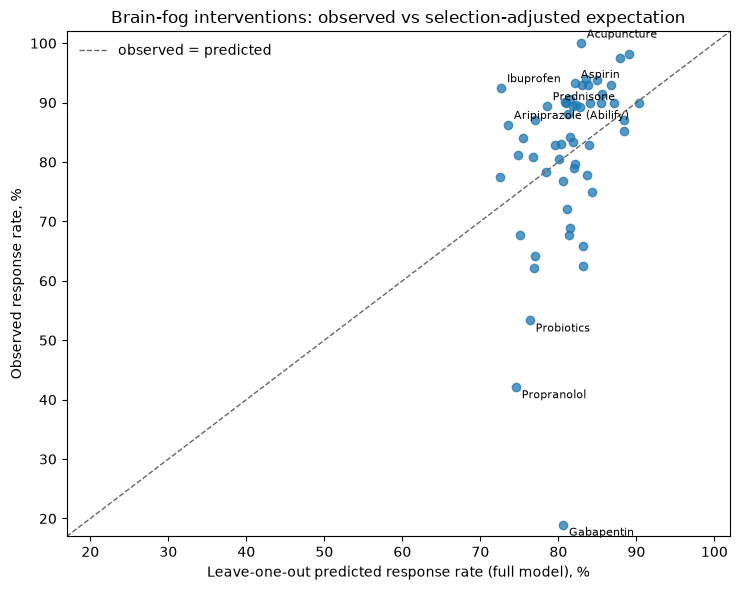

In [12]:
# How the original Bayesian top 5 and Psilocybin look after selection adjustment.
focus = [
    "Acupuncture",
    "Low-histamine diet",
    "Fish Oil",
    "Nicotine (patch/gum/unspecified)",
    "Fasting",
    "Psilocybin",
]
focus_view = residual_table[residual_table.treatment.isin(focus)].copy()
# Preserve the Bayesian ranking order for readability.
order = {name: i for i, name in enumerate(focus)}
focus_view["bayes_focus_order"] = focus_view.treatment.map(order)
focus_view = focus_view.sort_values("bayes_focus_order")

print("Original priority set under residual adjustment")
display(focus_view[[
    "treatment", "patients", "response_rate", "predicted_rate", "residual_pp", "residual_rank"
]].style.format({
    "response_rate": "{:.1f}%", "predicted_rate": "{:.1f}%", "residual_pp": "{:+.1f} pp",
}))

# Adjusted shortlist: residual leaders with enough patients to be more than a tiny cohort.
adjusted = residual_table[residual_table.patients >= 50].head(5)
print("\nAdjusted shortlist — top 5 by residual among interventions with ≥50 patients:")
for i, row in enumerate(adjusted.itertuples(index=False), 1):
    print(
        f"{i}. {row.treatment}: residual {row.residual_pp:+.1f} pp "
        f"(observed {row.response_rate:.1f}% vs expected {row.predicted_rate:.1f}%; n={int(row.patients)})"
    )

fig, ax = plt.subplots(figsize=(7.5, 6))
ax.scatter(residual_table.predicted_rate, residual_table.response_rate, s=36, alpha=0.75)
lims = [
    min(residual_table.predicted_rate.min(), residual_table.response_rate.min()) - 2,
    max(residual_table.predicted_rate.max(), residual_table.response_rate.max()) + 2,
]
ax.plot(lims, lims, color="0.4", linestyle="--", linewidth=1, label="observed = predicted")
for _, row in residual_table.head(5).iterrows():
    ax.annotate(row.treatment, (row.predicted_rate, row.response_rate), fontsize=8, xytext=(4, 4),
                textcoords="offset points")
for _, row in residual_table.tail(3).iterrows():
    ax.annotate(row.treatment, (row.predicted_rate, row.response_rate), fontsize=8, xytext=(4, -8),
                textcoords="offset points")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel(f"Leave-one-out predicted response rate ({active_label} model), %")
ax.set_ylabel("Observed response rate, %")
ax.set_title("Brain-fog interventions: observed vs selection-adjusted expectation")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### Review notes and updated reading

**What held up in review**

- Leave-one-intervention-out utility (not coefficient magnitude) is the right criterion at *n* = 54.
- Reporter other-treatment positivity and improving/recovered share are the main predictors — both are selection/prognosis effects, not treatment properties.
- Clinical averages (age, severity, duration, sex, treatment burden) add little or hurt CV, matching a “who posts” story more than a phenotype story.
- Strong ridge shrinkage (`α = 100` in every fold) is expected: the signal is weak relative to noise.

**What the residual continuation adds**

Raw Bayesian ranks answer “which interventions look best in the corpus.” Residuals ask a different question: “which still look unusually good after accounting for the kinds of patients who report them?” That second ranking is closer to an efficacy screen, though it remains observational and cannot remove Reddit self-selection, concurrent treatments, or extraction positivity bias.

Use the residual shortlist as a **second filter** on the Bayesian top set, not a replacement for sample-size and safety judgment. Treatments that are high on both raw rate and residual are the strongest hypothesis-generating candidates in this notebook.